In [ ]:

import wandb

api = wandb.Api()

In [ ]:
!export WANDB_API_KEY=36315659e0dddadabbe5efd509b05f435db05c50

In [ ]:
wandb.login()

True

In [ ]:
runs = api.runs("xiaoxionglin-bernstein-center-freiburg/SF_dmlab_NEMO_HiPPO3")

In [ ]:
all_results=dict()

In [ ]:
DG_names=['linear_relu','batchnorm_relu']
DG_code=['D','S']
core_names=['legt','legs','lagt']
core_code=['legt','legs','lagt']
for i_dense in range(2):

    DG_name=DG_names[i_dense]

    for i_archi in range(2,3):

        core_name=core_names[i_archi]

        dfs=[]
        for run in runs:
            if run.config['DG_name'] == DG_name and run.config['Hippo_measure']== core_name:
                print(run.name,run.config['Hippo_L'])
                cols = pd.Series(run.summary.keys())

                # build your regex: contains “raw” OR ends with reward_min, len/len, or global_step
                regex = r'raw|reward_min$|len/len$|global_step$'

                filtered = cols[cols.str.contains(regex, regex=True)].tolist()
                for j in range(1,4):

                    for i in range(4):
                        tmpdf2 = run.history(keys=filtered[i*4:i*4+j+1:j],samples=100000,pandas=True)
                        tmpdf=tmpdf2.groupby(tmpdf2[filtered[i*4]].apply(lambda x: 30000*(x//30000)))[filtered[i*4+j]].mean().reset_index(name=filtered[i*4+j])
                        # tmpdf.index.name=filtered[i*4]
                        dfs.append(tmpdf)
        for df in dfs:
            df.set_index(df.columns[0], inplace=True, drop=True)

        # 2) Build the union of all indices
        union_idx = dfs[0].index
        for df in dfs[1:]:
            union_idx = union_idx.union(df.index)

        # 3) Reindex + interpolate each DataFrame
        aligned = []
        for df in dfs:
            # Reindex to the full union (creates NaNs where missing)
            df2 = df.reindex(union_idx)
            # Interpolate numeric columns along the index
            df2_interp = df2.interpolate(method='index', limit_direction='both')
            aligned.append(df2_interp)

        # Now every df in `aligned` has the same index = union_idx, with NaNs filled.
        # You can concat or merge them directly:
        result = pd.concat(aligned, axis=1)

        all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"] = result

15_HiPPO3_D.nam_linear_relu_see_1111_H.mea_lagt_20250923_165644_086040 64
18_HiPPO3_D.nam_linear_relu_see_2222_H.mea_lagt_20250923_165646_963665 64
21_HiPPO3_D.nam_linear_relu_see_3333_H.mea_lagt_20250923_165650_220214 64
24_HiPPO3_D.nam_linear_relu_see_4444_H.mea_lagt_20250923_165655_673939 64
27_HiPPO3_D.nam_linear_relu_see_5555_H.mea_lagt_20250923_165657_004261 64
00_HiPPO3_D.nam_batchnorm_relu_see_1111_H.mea_lagt_20250923_165627_561437 64
03_HiPPO3_D.nam_batchnorm_relu_see_2222_H.mea_lagt_20250923_165630_641558 64
06_HiPPO3_D.nam_batchnorm_relu_see_3333_H.mea_lagt_20250923_165634_774614 64
09_HiPPO3_D.nam_batchnorm_relu_see_4444_H.mea_lagt_20250923_165636_682593 64
12_HiPPO3_D.nam_batchnorm_relu_see_5555_H.mea_lagt_20250923_165640_799650 64


linear_relu legt raw_score
nan nan
0.6505970646841813 0.2779768931412391
linear_relu legs raw_score
nan nan
0.6419362825796319 0.20919010323179973
linear_relu lagt raw_score
nan nan
0.3751652155000813 0.01567637203735214


/tmp/ipykernel_773353/3252385886.py:113: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(['']*len(ax[i].get_xticklabels()))


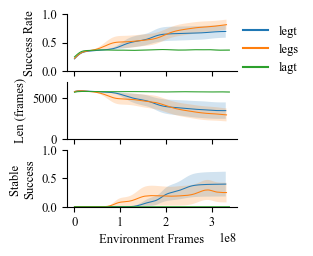

In [ ]:
DG_names=['linear_relu','batchnorm_relu']
DG_code=['D','S']
core_names=['legt','legs','lagt']
core_code=['legt','legs','lagt']

fig,ax=plt.subplots(3,1,figsize=(5.5*0.4, 2.5))

statsnames=[r'raw_score',r'len/len',r'reward_min']
normalize=[10,1,4.82]
colors=[]
for i_dense in range(1):

    DG_name=DG_names[i_dense]

    for i_archi in range(3):

        core_name=core_names[i_archi]

    # 1) Make sure each df is indexed by the same column:
    #    (if not already, e.g. df.set_index('Step', inplace=True))
    # df = all_results[f"{L}_{R}"]
    # df.plot(x=df.index.name or 'Index', title=f'L={L}, R={R}',legend=False,ax=ax[i],)    
        for i in range(3):
            tmp = all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].filter(regex=statsnames[i]).copy()
            # tmpdf=all_results[f"{L}_{R}"].filter(regex=statsnames[0]).copy()
            tmp = tmp.groupby(rand_labels[:tmp.shape[1]], axis=1).mean()
            # for key in tmp.columns:
            #     tmp[key]=gaussian_filter1d(tmp[key].values, sigma=10000,mode='nearest')
            tmp=gaussian_filter1d(tmp, axis=0, sigma=300,mode='nearest')
            tmp=tmp/normalize[i]
            means = tmp.mean(axis=1)
            stds  = tmp.std(axis=1)/np.sqrt(5)

            ax[i].plot(all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].index, means, color=f'C{i_archi}', lw=0.75)#, color=f'C{i}')

            # 2) draw a translucent band between mean–std and mean+std
            ax[i].fill_between(
                all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].index,
                means - stds,
                means + stds,
                # color=f'C{i}',    # match the line color
                alpha=0.2,     # control the band’s opacity
                # label='±1 std'
                linestyle='-'if i_dense==1 else '--',
                color=f'C{i_archi}',
                edgecolor=None
            )

            if i==0:
                idx=all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].index

                to90=np.zeros(5)
                for j in range(5):
                    if np.nonzero(tmp[:,j]>0.8)[0].size==0:
                        to90[j]=np.nan
                    else:
                        to90[j]=idx[np.nonzero(tmp[:,j]>0.8)[0][0]]

                success2m=np.zeros(5)
                idxidx=np.nonzero(idx>=200000000)[0][0]
                success2m=tmp[idxidx,:]

                print(DG_name,core_name,statsnames[i])
                print(to90.mean(),to90.std())
                print(success2m.mean(),success2m.std())

            # 2) draw a translucent band between mean–std and mean+std
            # ax[i].fill_between(
            #     all_results[f"{L}_{R}"].index,
            #     means - stds,
            #     means + stds,
            #     # color=f'C{i}',    # match the line color
            #     alpha=0.2,     # control the band’s opacity
            #     # label='±1 std'
            # )
            # 2) Plot error bars
            # ax[i].errorbar(
            #     x=all_results[f"{L}_{R}"].index,     # your index (e.g. Step or step_bin)
            #     y=means,#.values,    # the per-row means
            #     yerr=stds,#.values,  # the per-row standard deviations
            #     alpha=0.5
            #     # fmt='-o',          # line with circle markers
            #     # capsize=3,         # length of the errorbar “caps”
            #     # ecolor='gray',     # errorbar color
            #     # markerfacecolor='white',
            #     # markeredgecolor='C0'
            #     label=f"{L}_{R}"
            # )


ax[2].set_xlabel('Environment Frames')
# ax[0].set_ylabel('Success Rate')
# ax[1].set_ylabel('Trajectory Length (frames)')
# ax[2].set_ylabel('100 consecutive success')
ax[0].set_ylabel('Success Rate')#,fontsize=8)
ax[1].set_ylabel('Len (frames)')#,fontsize=8)
ax[2].set_ylabel('Stable \nSuccess')#,fontsize=8)

for i in range(3):
    ax[i].spines[['top','right']].set_visible(False)
i=0
env_names_short=['new Rew.','new map','block path']
for i_dense in range(1):

    DG_name=DG_names[i_dense]

    for i_archi in range(3):

        core_name=core_names[i_archi]
        ax[0].plot([], [], color=f'C{i_archi}', label=core_code[i_archi])
ax[0].legend(frameon=False,loc='upper left',bbox_to_anchor=(0.97, 1))
for i in range(2):
    ax[i].set_xticklabels(['']*len(ax[i].get_xticklabels()))
ax[1].set_ylim(0,7000)
ax[2].set_ylim(0,1)
ax[0].set_ylim(0,1)
fig.savefig('/home/xiaoxiong/Neuripsfigs/Dense_HiPPO_architectures.pdf',bbox_inches='tight',dpi=300)
# ax[].set_ylabel('Mean ± SD')
# ax.set_title('Per-row mean and standard deviation')

batchnorm_relu legt raw_score
nan nan
0.5651244422746028 0.14497595846319047
batchnorm_relu legs raw_score
nan nan
0.5151674904814633 0.10560732489159413
batchnorm_relu lagt raw_score
nan nan
0.6546496111858553 0.09567598058251917


/tmp/ipykernel_773353/713428865.py:113: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_xticklabels(['']*len(ax[i].get_xticklabels()))


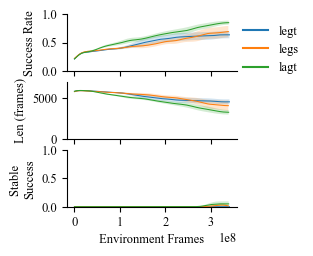

In [ ]:
DG_names=['linear_relu','batchnorm_relu']
DG_code=['D','S']
core_names=['legt','legs','lagt']
core_code=['legt','legs','lagt']

fig,ax=plt.subplots(3,1,figsize=(5.5*0.4, 2.5))

statsnames=[r'raw_score',r'len/len',r'reward_min']
normalize=[10,1,4.82]
colors=[]
for i_dense in range(1,2):

    DG_name=DG_names[i_dense]

    for i_archi in range(3):

        core_name=core_names[i_archi]

    # 1) Make sure each df is indexed by the same column:
    #    (if not already, e.g. df.set_index('Step', inplace=True))
    # df = all_results[f"{L}_{R}"]
    # df.plot(x=df.index.name or 'Index', title=f'L={L}, R={R}',legend=False,ax=ax[i],)    
        for i in range(3):
            tmp = all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].filter(regex=statsnames[i]).copy()
            # tmpdf=all_results[f"{L}_{R}"].filter(regex=statsnames[0]).copy()
            tmp = tmp.groupby(rand_labels[:tmp.shape[1]], axis=1).mean()
            # for key in tmp.columns:
            #     tmp[key]=gaussian_filter1d(tmp[key].values, sigma=10000,mode='nearest')
            tmp=gaussian_filter1d(tmp, axis=0, sigma=300,mode='nearest')
            tmp=tmp/normalize[i]
            means = tmp.mean(axis=1)
            stds  = tmp.std(axis=1)/np.sqrt(5)

            ax[i].plot(all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].index, means, color=f'C{i_archi}', lw=0.75)#, color=f'C{i}')

            # 2) draw a translucent band between mean–std and mean+std
            ax[i].fill_between(
                all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].index,
                means - stds,
                means + stds,
                # color=f'C{i}',    # match the line color
                alpha=0.2,     # control the band’s opacity
                # label='±1 std'
                linestyle='-'if i_dense==1 else '--',
                color=f'C{i_archi}',
                edgecolor=None
            )

            if i==0:
                idx=all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"].index

                to90=np.zeros(5)
                for j in range(5):
                    if np.nonzero(tmp[:,j]>0.8)[0].size==0:
                        to90[j]=np.nan
                    else:
                        to90[j]=idx[np.nonzero(tmp[:,j]>0.8)[0][0]]

                success2m=np.zeros(5)
                idxidx=np.nonzero(idx>=200000000)[0][0]
                success2m=tmp[idxidx,:]

                print(DG_name,core_name,statsnames[i])
                print(to90.mean(),to90.std())
                print(success2m.mean(),success2m.std())

            # 2) draw a translucent band between mean–std and mean+std
            # ax[i].fill_between(
            #     all_results[f"{L}_{R}"].index,
            #     means - stds,
            #     means + stds,
            #     # color=f'C{i}',    # match the line color
            #     alpha=0.2,     # control the band’s opacity
            #     # label='±1 std'
            # )
            # 2) Plot error bars
            # ax[i].errorbar(
            #     x=all_results[f"{L}_{R}"].index,     # your index (e.g. Step or step_bin)
            #     y=means,#.values,    # the per-row means
            #     yerr=stds,#.values,  # the per-row standard deviations
            #     alpha=0.5
            #     # fmt='-o',          # line with circle markers
            #     # capsize=3,         # length of the errorbar “caps”
            #     # ecolor='gray',     # errorbar color
            #     # markerfacecolor='white',
            #     # markeredgecolor='C0'
            #     label=f"{L}_{R}"
            # )


ax[2].set_xlabel('Environment Frames')
# ax[0].set_ylabel('Success Rate')
# ax[1].set_ylabel('Trajectory Length (frames)')
# ax[2].set_ylabel('100 consecutive success')
ax[0].set_ylabel('Success Rate')#,fontsize=8)
ax[1].set_ylabel('Len (frames)')#,fontsize=8)
ax[2].set_ylabel('Stable \nSuccess')#,fontsize=8)

for i in range(3):
    ax[i].spines[['top','right']].set_visible(False)
i=0
env_names_short=['new Rew.','new map','block path']
for i_dense in range(1,2):

    DG_name=DG_names[i_dense]

    for i_archi in range(3):

        core_name=core_names[i_archi]
        ax[0].plot([], [], color=f'C{i_archi}', label=core_code[i_archi])
ax[0].legend(frameon=False,loc='upper left',bbox_to_anchor=(0.97, 1))
for i in range(2):
    ax[i].set_xticklabels(['']*len(ax[i].get_xticklabels()))
ax[1].set_ylim(0,7000)
ax[2].set_ylim(0,1)
ax[0].set_ylim(0,1)
fig.savefig('/home/xiaoxiong/Neuripsfigs/Sparse_HiPPO_architectures.pdf',bbox_inches='tight',dpi=300)
# ax[].set_ylabel('Mean ± SD')
# ax.set_title('Per-row mean and standard deviation')